# Interval-Censored Density Estimation with HAL

This notebook uses the updated Stage-2 API:

- `do_over_smooth=False`: Stage 2A (direct EM from Stage 1, no oversmooth grid/CV)
- `do_over_smooth=True`: Stage 2B (oversmooth grid + EM)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.censoring import (
    IntervalCensoredInitTuner,
    IntervalCensoredEMTuner,
    incomplete_loglik_interval,
    kl_divergence,
)
from haldensity.utils import TruncatedGMM


/Users/zzp/Desktop/Github/HAL_Projects/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) Generate synthetic interval-censored data
np.random.seed(42)
n = 400

sampler_params = {
    'components': [
        {'mean': 0.2, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.8, 'std': 0.05, 'lower': 0, 'upper': 1},
    ],
    'weights': [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(**sampler_params)
t_event = sampler.generate_samples(n)

widths = np.random.uniform(0.05, 0.15, size=n)
left_shift = np.random.uniform(0, 1, size=n) * widths
L = np.clip(t_event - left_shift, 0.0, 1.0)
R = np.clip(L + widths, 0.0, 1.0)
R = np.maximum(R, L + 0.01)
R = np.minimum(R, 1.0)
data = pd.DataFrame({'L': L, 'R': R})

print(f'n={n}')
print(f'Mean interval width: {(R - L).mean():.3f}')
data.head()


n=400
Mean interval width: 0.102


,L,R
0,0.643348,0.790147
1,0.725043,0.846139
2,0.185221,0.255171
3,0.415507,0.539132
4,0.060642,0.163626


In [3]:
# 2) Stage 1 (Init): midpoint HAL-MLE tuned by CV
init_tuner = IntervalCensoredInitTuner(
    data=data,
    cv_folds=5,
    n_grid_points=100,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': [0]}
init_result = init_tuner.optimize(n_trials=20)

print('Stage 1 (Init):')
print('  best_params:', init_result.best_params)
print('  n_selected_knots:', int(init_result.estimator.get_results()['n_selected_knots']))


Stage 1 (Init):
  best_params: {'norm_constraint': 9.624745549540103, 'basis_order': 0}
  n_selected_knots: 37


In [4]:
# 3A) Stage 2A: no oversmooth (direct EM from Stage 1)
em_result_no_oversmooth = IntervalCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=False,
    em_m_imputations=50,
    em_max_em_iter=20,
    em_tol=1e-3,
    em_norm_factor=1.0,
    n_grid_points=100,
    random_state=42,
    silent=True,
).optimize()

print('Stage 2A (no oversmooth):')
print('  best_params:', em_result_no_oversmooth.best_params)
print('  mode:', em_result_no_oversmooth.metadata['mode'])


Stage 2A (no oversmooth):
  best_params: {'oversmooth_factor': 1.0, 'em_norm_factor': 1.0}
  mode: no_oversmooth


In [5]:
# 3B) Stage 2B: oversmooth grid + EM
em_result_oversmooth = IntervalCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    do_over_smooth=True,
    oversmooth_factors=[0.6, 0.7, 0.8, 0.9, 1.0],
    em_m_imputations=50,
    em_max_em_iter=20,
    em_tol=1e-3,
    em_norm_factor=1.6,
    n_grid_points=100,
    random_state=42,
    silent=True,
).optimize()

print('Stage 2B (oversmooth):')
print('  best_params:', em_result_oversmooth.best_params)
print('  mode:', em_result_oversmooth.metadata['mode'])


Stage 2B (oversmooth):
  best_params: {'oversmooth_factor': 0.6, 'em_norm_factor': 1.6}
  mode: oversmooth


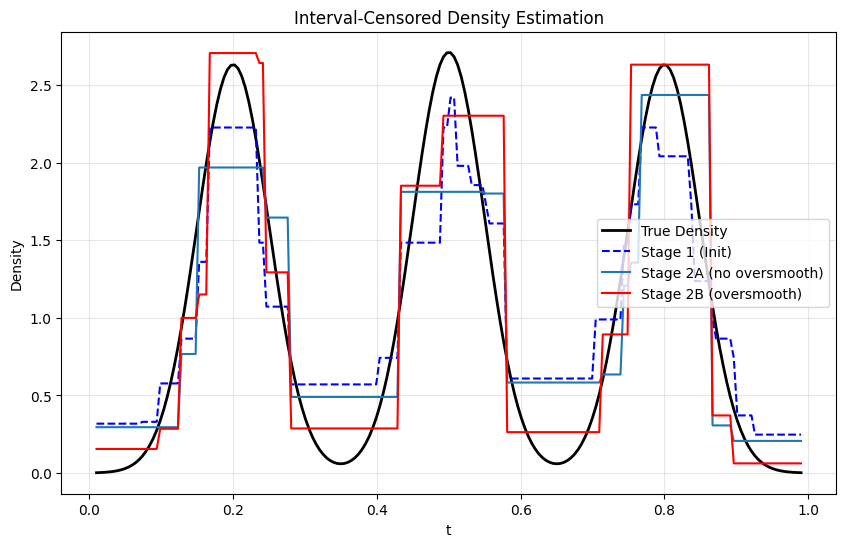

In [6]:
# 4) Compare densities
grid = np.linspace(0.01, 0.99, 200)
true_density = sampler.compute_density(grid)
init_density = init_result.estimator.get_density_at_points(grid)
stage2a_density = em_result_no_oversmooth.estimator.get_density_at_points(grid)
stage2b_density = em_result_oversmooth.estimator.get_density_at_points(grid)

plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', lw=2, label='True Density')
plt.plot(grid, init_density, 'b--', lw=1.5, label='Stage 1 (Init)')
plt.plot(grid, stage2a_density, color='tab:blue', lw=1.5, label='Stage 2A (no oversmooth)')
plt.plot(grid, stage2b_density, 'r-', lw=1.5, label='Stage 2B (oversmooth)')
plt.xlabel('t')
plt.ylabel('Density')
plt.title('Interval-Censored Density Estimation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [7]:
# 5) Log-likelihood and KL diagnostics
ll_init = float(incomplete_loglik_interval(init_result.estimator, data))
ll_2a = float(incomplete_loglik_interval(em_result_no_oversmooth.estimator, data))
ll_2b = float(incomplete_loglik_interval(em_result_oversmooth.estimator, data))

grid_kl = np.linspace(0.001, 0.999, 4000)
kl_init = float(kl_divergence(sampler.compute_density, grid_kl, init_result.estimator.get_density_at_points(grid_kl)))
kl_2a = float(kl_divergence(sampler.compute_density, grid_kl, em_result_no_oversmooth.estimator.get_density_at_points(grid_kl)))
kl_2b = float(kl_divergence(sampler.compute_density, grid_kl, em_result_oversmooth.estimator.get_density_at_points(grid_kl)))

print('Incomplete-data log-likelihood:')
print(f'  Stage 1:  {ll_init:.4f}')
print(f'  Stage 2A: {ll_2a:.4f}')
print(f'  Stage 2B: {ll_2b:.4f}')

print('KL(true || est):')
print(f'  Stage 1:  {kl_init:.6f}')
print(f'  Stage 2A: {kl_2a:.6f}')
print(f'  Stage 2B: {kl_2b:.6f}')

print('n_selected_knots:')
print('  Stage 1:', int(init_result.estimator.get_results()['n_selected_knots']))
print('  Stage 2A:', int(em_result_no_oversmooth.estimator.get_results()['n_selected_knots']))
print('  Stage 2B:', int(em_result_oversmooth.estimator.get_results()['n_selected_knots']))


Incomplete-data log-likelihood:
  Stage 1:  -818.4861
  Stage 2A: -809.7689
  Stage 2B: -793.6867
KL(true || est):
  Stage 1:  0.111920
  Stage 2A: 0.120278
  Stage 2B: 0.085388
n_selected_knots:
  Stage 1: 37
  Stage 2A: 37
  Stage 2B: 21
